In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from doubleml import DoubleMLPLR, DoubleMLPLIV
from doubleml import DoubleMLData
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")

# ── automatically find project root (works from any subfolder) ─────────
current = Path.cwd()
PROJ = current
while PROJ != PROJ.parent:
    if (PROJ / "data").exists() and (PROJ / "src").exists():
        break
    PROJ = PROJ.parent

DATA    = PROJ / "data"   / "final"  / "feature_matrix_nlp_FINAL.csv"
OUT_CSV = PROJ / "results" / "dml_primary_irf.csv"
OUT_FIG = PROJ / "figures" / "irf_dml_primary.png"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
OUT_FIG.parent.mkdir(parents=True, exist_ok=True)

# ── load final matrix ─────────────────────────────────────────────────
df = pd.read_csv(DATA, index_col=0, parse_dates=True)
print(f"Loaded: {df.shape[0]} obs × {df.shape[1]} cols")
print(f"Project root = {PROJ}")

Loaded: 386 obs × 127 cols
Project root = c:\Users\HP\Desktop\replication+contribution


In [ ]:
# Treatment, outcome, instrument
Y      = "lwti"
T      = "lpri"
Z      = "d2pri"

# Primary controls (full coverage, 62 variables)
PRIMARY_CONTROLS = [
    'llwip', 'dllgop', 'l2lwip', 'dl2lgop',
    'dlpri_jp', 'dlpri_aus', 'dlpri_cds', 'dlpri_fra', 'dlpri_ger',
    'dlpri_india', 'dlpri_indo', 'dlpri_pak', 'dlpri_rus', 'dlpri_vn', 'dlpri_uk',
    'vix', 'dvix', 'gs10', 'tb3ms', 'term_spread', 'tedrate', 'us_spread',
    'lreer', 'dcny_usd', 'cny_vol', 'lgold', 'brent_wti_spread', 'lbdi', 'lip',
    'gdelt_total_events_log', 'gdelt_protest_share', 'gdelt_military_share',
    'gdelt_diplomatic_share', 'gdelt_goldstein_mean', 'gdelt_sentiment_signal',
    'gdelt_topic_01_statement', 'gdelt_topic_02_appeal', 'gdelt_topic_03_intent_cooperate',
    'gdelt_topic_04_consult', 'gdelt_topic_05_diplomatic_coop', 'gdelt_topic_06_material_coop',
    'gdelt_topic_07_provide_aid', 'gdelt_topic_08_yield', 'gdelt_topic_09_investigate',
    'gdelt_topic_10_demand', 'gdelt_topic_11_disapprove', 'gdelt_topic_12_reject',
    'gdelt_topic_13_threaten', 'gdelt_topic_14_protest', 'gdelt_topic_15_exhibit_force',
    'gdelt_topic_16_reduce_relations', 'gdelt_topic_17_coerce', 'gdelt_topic_18_assault',
    'gdelt_topic_19_fight', 'gdelt_topic_20_mass_violence',
    'gdelt_conflict_share', 'gdelt_coop_share', 'gdelt_hostility_share',
    'gpr', 'gpr_threats', 'gpr_acts', 'wui',
]

# Ensure all columns exist
missing = [c for c in PRIMARY_CONTROLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")
print(f"Primary controls: {len(PRIMARY_CONTROLS)} variables")

Primary controls: 62 variables


In [33]:
# Create lagged lwti and lpri (matching Saadaoui's first stage)
for lag in range(1, 4):
    df[f"L{lag}_lwti"] = df["lwti"].shift(lag)
for lag in range(1, 3):
    df[f"L{lag}_lpri"] = df["lpri"].shift(lag)

# Append the lags to the primary controls
LAG_CONTROLS = ["L1_lwti", "L2_lwti", "L3_lwti", "L1_lpri", "L2_lpri"]
PRIMARY_CONTROLS = PRIMARY_CONTROLS + LAG_CONTROLS

print(f"Updated primary controls: {len(PRIMARY_CONTROLS)} variables")

Updated primary controls: 67 variables


In [34]:
# Drop rows where any required variable is null
vars_needed = [Y, T, Z] + PRIMARY_CONTROLS
df_reg = df[vars_needed].dropna()
print(f"First‑stage sample: {len(df_reg)} obs")

X_first = df_reg[PRIMARY_CONTROLS + [Z]]
y_first = df_reg[T]

# Linear first stage (same as Saadaoui)
from statsmodels.api import OLS, add_constant
model_fs = OLS(y_first, add_constant(X_first)).fit()

# F-test on the instrument (d2pri)
z_idx = list(model_fs.params.index).index(Z)   # safe column lookup
r_matrix = np.zeros((1, len(model_fs.params)))
r_matrix[0, z_idx] = 1
f_stat = model_fs.f_test(r_matrix)
print(f"First‑stage F‑stat (linear, on instrument): {f_stat.fvalue:.3f}")

# ML‑based first stage (for completeness)
rf_fs = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_fs.fit(X_first, y_first)
r2_ml = rf_fs.score(X_first, y_first)
print(f"First‑stage R² (random forest): {r2_ml:.4f}")

First‑stage sample: 333 obs
First‑stage F‑stat (linear, on instrument): 85.350
First‑stage R² (random forest): 0.9957


In [27]:
# ── Minimal first stage (only baseline controls, as in Saadaoui)
base_vars = ['llwip', 'dllgop', 'l2lwip', 'dl2lgop']
df_min = df[base_vars + [Y, T, Z]].dropna()
X_min = df_min[base_vars + [Z]]
y_min = df_min[T]

model_min = OLS(y_min, add_constant(X_min)).fit()
z_idx_min = list(model_min.params.index).index(Z)
r_min = np.zeros((1, len(model_min.params)))
r_min[0, z_idx_min] = 1
f_min = model_min.f_test(r_min)
print(f"First‑stage F‑stat (baseline controls only): {f_min.fvalue:.3f}")

First‑stage F‑stat (baseline controls only): 0.061


In [28]:
np.random.seed(42)
HORIZONS = list(range(0, 49))
results   = []

# Learners – identical random forests for all nuisance functions
ml_g = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_r = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

for h in HORIZONS:
    # Create lead of outcome
    df[f"lwti_lead_{h}"] = df[Y].shift(-h)

    # Build working dataset for horizon h
    cols = [f"lwti_lead_{h}", T, Z] + PRIMARY_CONTROLS
    df_h = df[cols].dropna().copy()

    # DoubleML data object – correct plural parameters
    dml_data = DoubleMLData(
        df_h,
        y_col   = f"lwti_lead_{h}",
        d_cols  = T,
        z_cols  = Z,
        x_cols  = PRIMARY_CONTROLS,
    )

    dml_obj = DoubleMLPLIV(
        dml_data,
        ml_g=ml_g,
        ml_m=ml_m,
        ml_l=ml_l,
        ml_r=ml_r,
        n_folds=5,
        n_rep=1,
    )
    dml_obj.fit()

    results.append({
        "horizon": h,
        "coef"   : dml_obj.coef.item(),
        "se"     : dml_obj.se.item(),
        "n_obs"  : df_h.shape[0],
    })

    df.drop(columns=[f"lwti_lead_{h}"], inplace=True)

    if h % 12 == 0:
        print(f"  h={h:2d}  β={dml_obj.coef.item():+.5f}  SE={dml_obj.se.item():.5f}  N={df_h.shape[0]}")

df_irf = pd.DataFrame(results)
df_irf.to_csv(OUT_CSV, index=False)
print(f"\nImpulse responses saved → {OUT_CSV}")

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(


  h= 0  β=+0.04231  SE=0.14980  N=333


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required f

  h=12  β=+0.11308  SE=0.26955  N=325


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required f

  h=24  β=-0.09491  SE=0.23962  N=313


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required f

  h=36  β=-0.12290  SE=0.33398  N=301


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required f

  h=48  β=-0.07982  SE=0.17399  N=289

Impulse responses saved → c:\Users\HP\Desktop\replication+contribution\results\dml_primary_irf.csv


In [31]:
LEAD_HORIZONS = list(range(-6, 0))
lead_results = []

for h in LEAD_HORIZONS:
    df[f"lwti_lead_{h}"] = df[Y].shift(-h)

    cols = [f"lwti_lead_{h}", T, Z] + PRIMARY_CONTROLS
    df_h = df[cols].dropna().copy()

    # DoubleML data object – same pattern as the main loop
    dml_data = DoubleMLData(
        df_h,
        y_col   = f"lwti_lead_{h}",
        d_cols  = T,
        z_cols  = Z,
        x_cols  = PRIMARY_CONTROLS,
    )

    dml_obj = DoubleMLPLIV(
        dml_data,
        ml_g=ml_g,
        ml_m=ml_m,
        ml_l=ml_l,   # re‑using the learners defined in Cell 4
        ml_r=ml_r,
        n_folds=5,
        n_rep=1,
    )
    dml_obj.fit()

    lead_results.append({
        "horizon": h,
        "coef"   : dml_obj.coef.item(),
        "se"     : dml_obj.se.item(),
    })

    df.drop(columns=[f"lwti_lead_{h}"], inplace=True)

df_lead = pd.DataFrame(lead_results)
print(df_lead)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required for estimation.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\doubleml\plm\pliv.py:126: UserWarning: A learner ml_g has been provided for score = "partialling out" but will be ignored. "A learner ml_g is not required f

   horizon      coef        se
0       -6 -0.105882  1.119526
1       -5 -0.083429  0.258460
2       -4 -0.152207  0.324865
3       -3 -0.001995  0.613394
4       -2 -0.004876  0.259862
5       -1  0.096207  0.107806


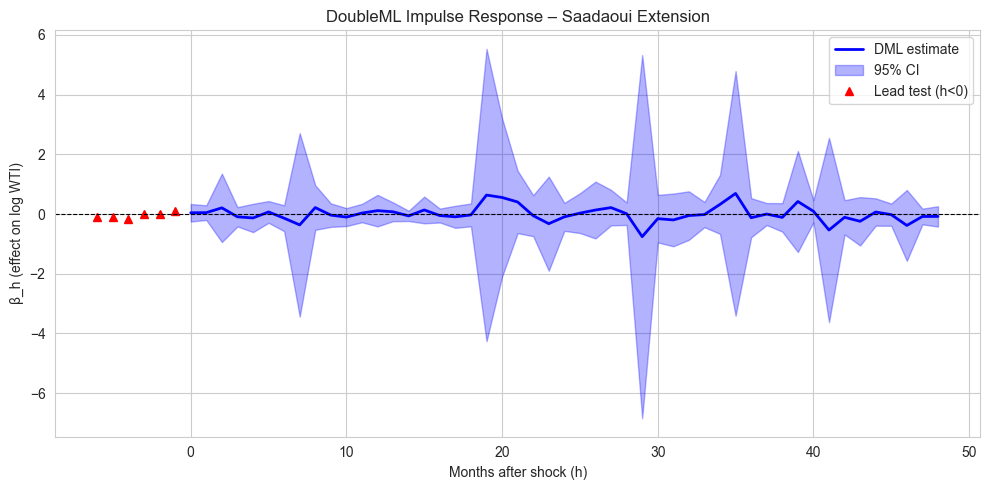

Figure saved → c:\Users\HP\Desktop\replication+contribution\figures\irf_dml_primary.png


In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

# Main IRF
ax.plot(df_irf["horizon"], df_irf["coef"], "b-", lw=2, label="DML estimate")
ax.fill_between(df_irf["horizon"],
                df_irf["coef"] - 1.96 * df_irf["se"],
                df_irf["coef"] + 1.96 * df_irf["se"],
                alpha=0.3, color="b", label="95% CI")

# Add lead test points
if len(df_lead) > 0:
    ax.plot(df_lead["horizon"], df_lead["coef"], "r^", ms=6, label="Lead test (h<0)")

ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel("Months after shock (h)")
ax.set_ylabel("β_h (effect on log WTI)")
ax.set_title("DoubleML Impulse Response – Saadaoui Extension")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_FIG, dpi=150)
plt.show()
print(f"Figure saved → {OUT_FIG}")